# 08: Sample Selection Models

We work through sample-selection models with `DoubleML`. The central problem is outcome attrition: we want a causal effect for a target population, but the outcome is observed only for a selected subset of rows.

This comes up constantly in applied data work. A user may only leave a rating if they engaged. A customer satisfaction survey may only be answered by a nonrandom subset. A downstream business outcome may only be measured after a user completes an earlier funnel step. If we estimate treatment effects only on the selected rows, the result can describe the selected sample rather than the full target population.

`DoubleMLSSM` handles this setting by combining treatment propensity learning, selection-probability learning, and outcome regression. The machine learning helps estimate nuisance functions flexibly; the causal validity still comes from assumptions about treatment assignment and outcome observation.

## Learning Goals

By the end, you should be able to:

- identify when selected outcomes threaten causal effect estimation;
- distinguish treatment selection from sample selection;
- explain missing-at-random selection and nonignorable selection;
- build `DoubleMLSSMData` with outcome, treatment, covariates, selection indicator, and optional selection instrument;
- fit `DoubleMLSSM` with linear and tree-based nuisance learners;
- inspect outcome, treatment, and selection nuisance predictions;
- understand why unselected rows must remain in the dataset;
- report selection assumptions, overlap concerns, and sensitivity risks clearly.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Sample Selection Models**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment makes observation itself part of the design. Selection models ask whether the observed sample can support a claim about the target population.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

Sample selection problems arise when the outcome is observed only for selected units. Let $S_i=1$ indicate that $Y_i$ is observed. A selection probability is

$$
s(X_i,D_i)=\Pr(S_i=1\mid X_i,D_i).
$$

Inverse-selection weighting corrects the observed sample by weighting observed outcomes by $1/s(X_i,D_i)$. Small selection probabilities create unstable weights, so support is part of the causal design.





## Tutorial Workflow

### The Selection Problem

A standard binary-treatment ATE problem has an outcome `Y`, treatment `D`, and covariates `X`. Sample selection adds another variable, `S`:

```text
S = 1 if the outcome is observed
S = 0 if the outcome is missing or not measured
```

The dangerous shortcut is to drop rows with `S = 0` and run a treatment-effect model on selected rows only. That selected-row analysis answers a different question unless selection is completely unrelated to potential outcomes and treatment effects.

Sample selection is not the same as treatment selection. Treatment selection asks why `D` differs across rows. Sample selection asks why `Y` is observed for some rows and not others. In selected-outcome problems, we often need nuisance models for both.




## Diagnostics and Interpretation

### Missing-At-Random Selection

The missing-at-random version assumes that, after conditioning on treatment and observed covariates, whether the outcome is observed does not depend on the missing potential outcomes.

In words:

```text
Outcome observation can depend on D and X,
but not on hidden outcome shocks once D and X are fixed.
```

This is a strong assumption, but it can be plausible in some settings. For example, if survey response depends on known user activity, tenure, device type, and treatment status, and those variables capture the relevant response process, a missing-at-random correction may be credible.

The key nuisance functions are:

- `g(d, X) = E[Y | S = 1, D = d, X]`, the outcome model among selected rows;
- `pi(D, X) = P(S = 1 | D, X)`, the selection probability;
- `m(X) = P(D = 1 | X)`, the treatment propensity.

DoubleML combines these through an orthogonal score so that nuisance estimation error has less first-order impact on the final treatment-effect estimate.



### Nonignorable Selection

Sometimes outcome observation depends on hidden factors that also affect the outcome. This is nonignorable selection. A satisfaction survey may be more likely to be answered by unusually happy or unusually unhappy users even after conditioning on observed covariates. In that case, missing-at-random adjustment can still be biased.

`DoubleMLSSM` also supports a `nonignorable` score. That setup requires an instrument-like variable for selection: a variable that affects whether the outcome is observed but does not directly affect the outcome itself. In this lesson we call it `selection_encouragement`.

The exclusion restriction is doing real causal work. The package can use the variable. The claim that it affects selection only through observation still needs substantive justification.

### What DoubleML Adds

The sample-selection score is a doubly robust style construction. For the missing-at-random case, the treatment arm contribution looks like:

```text
D * S * (Y - g(1, X)) / [m(X) * pi(1, X)] + g(1, X)
```

The control arm has the analogous term with `1 - D` and `g(0, X)`. The ATE estimate is the average treatment contribution minus the average control contribution.

This structure explains the three nuisance roles:

- the outcome model fills in expected outcomes;
- the treatment propensity adjusts for treatment assignment;
- the selection probability upweights observed outcomes to represent rows whose outcomes are missing.

Cross-fitting keeps nuisance predictions out of sample. Orthogonality makes the final estimate less sensitive to small nuisance-model errors, but it does not remove the need for selection assumptions and overlap.

#### Runtime Note

This lesson fits several sample-selection models, including stress tests and a nonignorable-selection example. A full run should take about 2 to 4 minutes on a typical laptop.

#### Setup

The setup cell imports the scientific Python stack, configures output folders, and suppresses only the narrow warnings that would clutter tutorial output. Code is kept visible throughout the notebook.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        PROJECT_ROOT = candidate
        break

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*", category=Warning)
warnings.filterwarnings("ignore", message=".*trimming.*deprecated.*", category=DeprecationWarning)

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import sklearn
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.formula.api as smf

import doubleml as dml
from doubleml import DoubleMLSSM, DoubleMLSSMData

NOTEBOOK_PREFIX = "08"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

package_versions = pd.DataFrame(
    [
        {"package": "python", "version": os.sys.version.split()[0]},
        {"package": "doubleml", "version": dml.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "matplotlib", "version": plt.matplotlib.__version__},
        {"package": "seaborn", "version": sns.__version__},
    ]
)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)


,package,version
0,python,3.11.15
1,doubleml,0.11.2
2,numpy,2.4.4
3,pandas,3.0.2
4,scikit-learn,1.6.1
5,matplotlib,3.10.9
6,seaborn,0.13.2


The version table is part of the reproducibility record. The installed version exposes `DoubleMLSSM` and `DoubleMLSSMData`, which are the two classes used in this tutorial.

#### Helper Functions

The helpers below keep the notebook readable. They save tables, construct nuisance learners, extract DoubleML predictions, and compute compact diagnostics. None of them changes the causal estimand.

In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, file_name, index=False):
    """
    Save a table under the notebook output folder and return the DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    file_name : str
        Readable label for `file`.
    index : object
        Position of a row, variable, fold, or plotted node in the relevant ordered object.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / file_name
    df.to_csv(path, index=index)
    return df


def sigmoid(x):
    """
    Logistic transform used for synthetic probabilities.
    
    Parameters
    ----------
    x : str or array-like
        First variable, column name, or numeric input in the local calculation.
    
    Returns
    -------
    np.ndarray
        Probability-scale values obtained by applying the logistic transform elementwise.
    """
    return 1.0 / (1.0 + np.exp(-x))


def rmse(y_true, y_pred):
    """
    Root mean squared error with one-dimensional arrays.
    
    Parameters
    ----------
    y_true : array-like
        Reference or oracle values used for evaluation.
    y_pred : array-like
        Predicted or estimated values being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(np.asarray(y_true).ravel(), np.asarray(y_pred).ravel())))


def clip_probability(values, lower=0.01, upper=0.99):
    """
    Clip probabilities away from exact 0 and 1 for stable inverse weights.
    
    Parameters
    ----------
    values : array-like
        Numeric values transformed, standardized, summarized, or plotted by the helper.
    lower : object
        Lower coordinate, lower interval bound, or lower plotting boundary used by the helper.
    upper : object
        Upper coordinate, upper interval bound, or upper plotting boundary used by the helper.
    
    Returns
    -------
    np.ndarray
        Probability vector clipped to the requested lower and upper bounds.
    """
    return np.clip(np.asarray(values, dtype=float), lower, upper)


def predict_probability(model, X):
    """
    Return P(class=1) from a classifier.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    X : object
        Covariate matrix used by the estimator, learner, or intervention function.
    
    Returns
    -------
    np.ndarray
        Predicted probability of the positive class for each evaluation row.
    """
    return model.predict_proba(X)[:, 1]


def make_linear_learners():
    """
    Low-variance nuisance learners for mostly linear synthetic designs.
    
    Returns
    -------
    tuple
        Tuple containing ml_g, ml_pi, ml_m.
    """
    ml_g = make_pipeline(StandardScaler(), LinearRegression())
    ml_pi = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1_000))
    ml_m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1_000))
    return ml_g, ml_pi, ml_m


def make_hgb_learners(seed=RANDOM_SEED, max_iter=80):
    """
    Tree-based nuisance learners for more flexible adjustment.
    
    Parameters
    ----------
    seed : int
        Random seed for reproducible simulation or resampling.
    max_iter : object
        Maximum number of learner iterations used for fitting.
    
    Returns
    -------
    tuple
        Tuple containing ml_g, ml_pi, ml_m.
    """
    ml_g = HistGradientBoostingRegressor(
        max_iter=max_iter,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        learning_rate=0.06,
        random_state=seed,
    )
    ml_pi = HistGradientBoostingClassifier(
        max_iter=max_iter,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        learning_rate=0.06,
        random_state=seed + 1,
    )
    ml_m = HistGradientBoostingClassifier(
        max_iter=max_iter,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        learning_rate=0.06,
        random_state=seed + 2,
    )
    return ml_g, ml_pi, ml_m


def prediction_vector(model, key):
    """
    Extract one DoubleML prediction array as a flat vector.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    key : object
        Prediction dictionary key identifying which stored nuisance prediction to extract.
    
    Returns
    -------
    np.ndarray
        One-dimensional prediction array aligned with the evaluation rows.
    """
    return np.asarray(model.predictions[key]).reshape(-1)


def summarize_doubleml(model, label, design, true_target):
    """
    Create a compact one-row summary from a fitted DoubleML object.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    label : str
        Readable label attached to the method, scenario, or output row.
    design : object
        Readable design label used to distinguish estimators or simulation settings.
    true_target : float
        Oracle causal target used to evaluate bias.
    
    Returns
    -------
    dict[str, float]
        DoubleML summary row with estimator label, design label, estimate, standard error, interval, target, and bias.
    """
    ci = model.confint(level=0.95).iloc[0]
    theta = float(model.coef[0])
    se = float(model.se[0])
    return {
        "estimator": label,
        "design": design,
        "theta_hat": theta,
        "std_error": se,
        "ci_95_lower": float(ci.iloc[0]),
        "ci_95_upper": float(ci.iloc[1]),
        "true_target": float(true_target),
        "bias_vs_target": theta - float(true_target),
    }


def learner_loss_table(model, model_label):
    """
    Convert DoubleML learner losses to a tidy table.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    model_label : str
        Readable label for `model`.
    
    Returns
    -------
    pd.DataFrame
        Out-of-fold nuisance prediction loss table by learner and nuisance role.
    """
    losses = model.evaluate_learners()
    rows = []
    for learner_name, values in losses.items():
        rows.append(
            {
                "model": model_label,
                "learner": learner_name,
                "metric_value": float(np.asarray(values).mean()),
                "metric": "RMSE for outcome learners; classification error style score for propensity learners",
            }
        )
    return pd.DataFrame(rows)


def add_ci_columns(df):
    """
    Prepare lower and upper error-bar columns for plotting.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    
    Returns
    -------
    pd.DataFrame
        Copy of the input table with lower and upper confidence-interval columns added.
    """
    out = df.copy()
    out["lower_error"] = out["theta_hat"] - out["ci_95_lower"]
    out["upper_error"] = out["ci_95_upper"] - out["theta_hat"]
    return out


The helper functions make the model code easier to read. The key idea to keep in mind is that SSM has three nuisance tasks: outcome regression, selection-probability modeling, and treatment-propensity modeling.

#### Teaching Diagram

The diagram separates treatment assignment from outcome observation. `D` determines which potential outcome is relevant. `S` determines whether we see that outcome. Both can depend on observed controls, and selection can also depend on treatment.

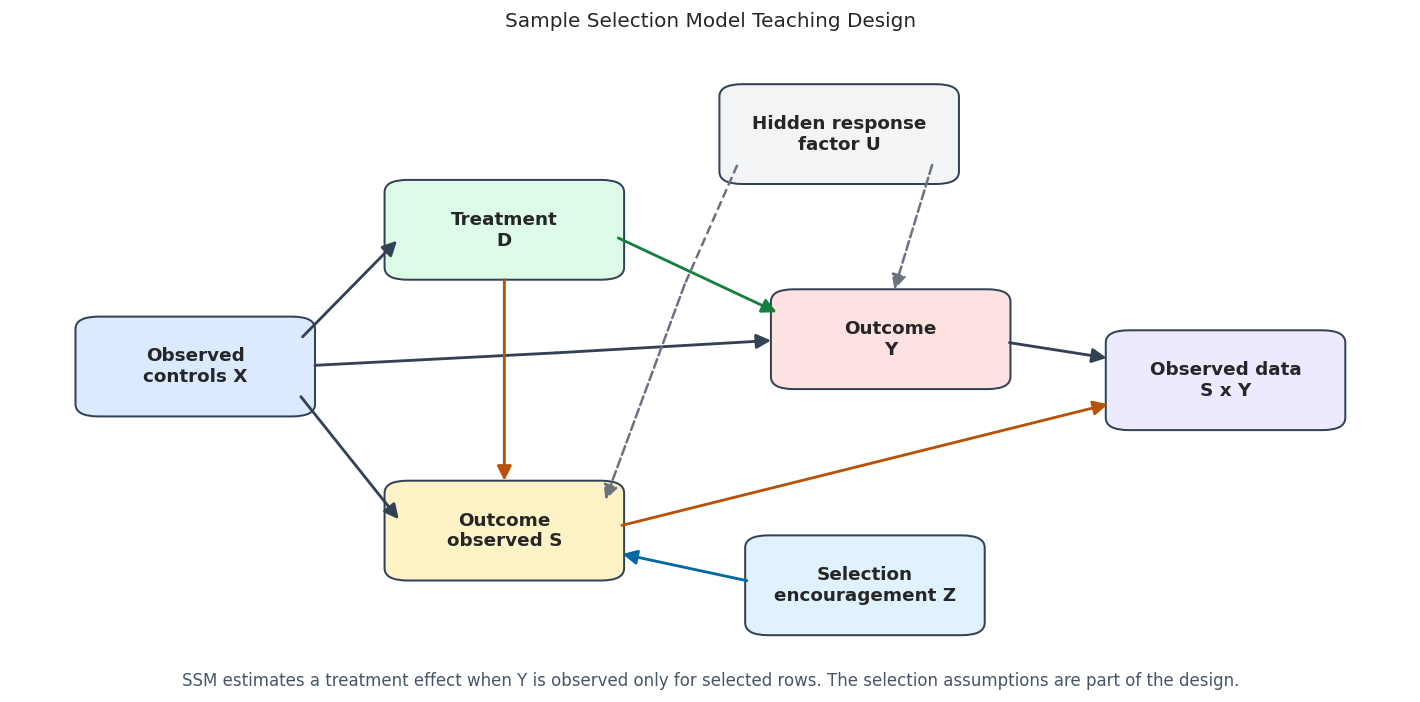

In [3]:
# Define reusable helpers for the Teaching Diagram section.
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

nodes = {
    "X": {"xy": (0.10, 0.54), "label": "Observed\ncontrols X", "color": "#dbeafe"},
    "D": {"xy": (0.34, 0.74), "label": "Treatment\nD", "color": "#dcfce7"},
    "S": {"xy": (0.34, 0.30), "label": "Outcome\nobserved S", "color": "#fef3c7"},
    "Y": {"xy": (0.64, 0.58), "label": "Outcome\nY", "color": "#fee2e2"},
    "Z": {"xy": (0.62, 0.22), "label": "Selection\nencouragement Z", "color": "#e0f2fe"},
    "U": {"xy": (0.60, 0.88), "label": "Hidden response\nfactor U", "color": "#f3f4f6"},
    "O": {"xy": (0.90, 0.52), "label": "Observed data\nS x Y", "color": "#ede9fe"},
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axis_off()
box_w, box_h = 0.15, 0.11
arrow_gap = 0.018


def anchor(node, side):
    """
    Idea: Return the plotting anchor point for a named node in the diagram.
    
    Parameters
    ----------
    node : object
        Graph node whose position, label, or incident edges are being processed.
    side : object
        Endpoint side used to place an arrow or edge on the correct part of a node.
    
    Returns
    -------
    tuple[float, float] or np.ndarray
        Coordinate of the requested side of a plotted node.
    """
    x, y = nodes[node]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return (x + dx, y + dy)


def shorten_segment(start, end, gap=arrow_gap):
    """
    Move arrow endpoints inward so arrowheads do not sit on top of boxes.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    end : tuple[float, float]
        Ending coordinate of the arrow or edge segment.
    gap : float
        Extra spacing between an edge endpoint and a node boundary.
    
    Returns
    -------
    tuple
        Coordinate pair or coordinate pairs used to place arrows cleanly in the diagram.
    """
    start = np.asarray(start, dtype=float)
    end = np.asarray(end, dtype=float)
    delta = end - start
    length = np.hypot(delta[0], delta[1])
    if length == 0:
        return tuple(start), tuple(end)
    unit = delta / length
    return tuple(start + gap * unit), tuple(end - gap * unit)


def shorten_polyline(points, gap=arrow_gap):
    """
    Shorten only the first and final endpoints of a routed arrow.
    
    Parameters
    ----------
    points : list[tuple[float, float]]
        Polyline points used to route an arrow.
    gap : float
        Extra spacing between an edge endpoint and a node boundary.
    
    Returns
    -------
    list[tuple[float, float]]
        Polyline coordinates shortened so line endpoints do not overlap node boxes.
    """
    pts = [tuple(point) for point in points]
    if len(pts) < 2:
        return pts
    pts[0], _ = shorten_segment(pts[0], pts[1], gap=gap)
    _, pts[-1] = shorten_segment(pts[-2], pts[-1], gap=gap)
    return pts


def draw_arrow(start, end, color, style="solid", rad=0.0, linewidth=1.7, gap=arrow_gap):
    """
    Idea: Draw a routed arrow between diagram nodes while keeping the arrowhead visible.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    rad : float
        Curvature parameter for the plotted arrow.
    linewidth : object
        Line width used to make the plotted edge or reference line readable.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    start, end = shorten_segment(start, end, gap=gap)
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        shrinkA=0,
        shrinkB=0,
        connectionstyle=f"arc3,rad={rad}",
        zorder=5,
    )
    ax.add_patch(arrow)


def draw_routed_arrow(points, color, style="solid", linewidth=1.7, gap=arrow_gap):
    """
    Idea: Draw an arrow along a routed path so it avoids overlapping nearby nodes.
    
    Parameters
    ----------
    points : object
        Coordinates or values used to draw the plotted object.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    linewidth : object
        Line width used to make the plotted edge or reference line readable.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    None
        Adds a routed arrow annotation directly to the supplied Matplotlib axes.
    """
    pts = shorten_polyline(points, gap=gap)
    for start, end in zip(pts[:-2], pts[1:-1]):
        ax.plot([start[0], end[0]], [start[1], end[1]], color=color, linestyle=style, linewidth=linewidth, zorder=5)
    draw_arrow(pts[-2], pts[-1], color=color, style=style, linewidth=linewidth, gap=0.0)

# Main observed paths.
draw_arrow(anchor("X", "upper_right"), anchor("D", "left"), color="#334155")
draw_arrow(anchor("X", "lower_right"), anchor("S", "left"), color="#334155")
draw_routed_arrow([anchor("X", "right"), (0.38, 0.56), anchor("Y", "left")], color="#334155")
draw_arrow(anchor("D", "right"), anchor("Y", "upper_left"), color="#15803d")
draw_arrow(anchor("D", "bottom"), anchor("S", "top"), color="#b45309")
draw_arrow(anchor("Z", "left"), anchor("S", "lower_right"), color="#0369a1")
draw_arrow(anchor("Y", "right"), anchor("O", "upper_left"), color="#334155")
draw_arrow(anchor("S", "right"), anchor("O", "lower_left"), color="#b45309")

# Dashed paths are separated so the nonignorable-selection risk is visible without crossing boxes.
draw_arrow(anchor("U", "lower_right"), anchor("Y", "top"), color="#6b7280", style="dashed", linewidth=1.5)
draw_routed_arrow([anchor("U", "lower_left"), (0.48, 0.66), anchor("S", "upper_right")], color="#6b7280", style="dashed", linewidth=1.5)

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

ax.text(
    0.50,
    0.08,
    "SSM estimates a treatment effect when Y is observed only for selected rows. The selection assumptions are part of the design.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Sample Selection Model Teaching Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_ssm_design_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The dashed paths show the nonignorable-selection risk. If a hidden response factor affects both outcome observation and the outcome itself, a missing-at-random correction can fail. The selection encouragement `Z` is useful only if it shifts observation without directly shifting the outcome.



#### Synthetic Missing-At-Random Data

The first dataset is a missing-at-random design. Selection depends on treatment and observed covariates, including a selection encouragement signal. There is no hidden response factor that directly affects both selection and the outcome.

Because this is synthetic data, we keep a `full_outcome` column for evaluation. In real selected-outcome data, that full outcome would not be available for unselected rows.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
N_MAR = 6_000

engagement_score = rng.normal(0, 1, N_MAR)
baseline_value = rng.normal(0, 1, N_MAR)
support_need = rng.normal(0, 1, N_MAR)
prior_usage = rng.normal(0, 1, N_MAR)
mobile_user = rng.binomial(1, 0.48, N_MAR)
selection_encouragement = rng.normal(0, 1, N_MAR)

mar_x = pd.DataFrame(
    {
        "engagement_score": engagement_score,
        "baseline_value": baseline_value,
        "support_need": support_need,
        "prior_usage": prior_usage,
        "mobile_user": mobile_user,
        "selection_encouragement": selection_encouragement,
    }
)
feature_cols_mar = list(mar_x.columns)

true_treatment_propensity = sigmoid(
    -0.10
    + 0.55 * engagement_score
    + 0.35 * baseline_value
    - 0.30 * support_need
    + 0.18 * mobile_user
)
treated = rng.binomial(1, true_treatment_propensity)

true_tau = 1.00 + 0.25 * engagement_score + 0.15 * baseline_value - 0.10 * support_need + 0.08 * mobile_user
mu0 = 3.00 + 0.80 * engagement_score + 0.50 * baseline_value - 0.30 * support_need + 0.25 * prior_usage + 0.20 * mobile_user
full_outcome = mu0 + true_tau * treated + rng.normal(0, 0.70, N_MAR)

true_selection_probability = sigmoid(
    -0.25
    + 0.55 * treated
    + 0.45 * engagement_score
    - 0.55 * support_need
    + 0.25 * prior_usage
    + 0.70 * selection_encouragement
)
selected = rng.binomial(1, true_selection_probability)

# DoubleMLSSM expects a numeric outcome column for every row. The selection indicator tells the estimator
# which outcomes are genuinely observed and should enter the selected-outcome regressions.
outcome_observed = full_outcome.copy()
outcome_observed[selected == 0] = 0.0

mar_df = pd.concat(
    [
        pd.DataFrame({"row_id": np.arange(N_MAR)}),
        mar_x,
        pd.DataFrame(
            {
                "treated": treated,
                "selected": selected,
                "outcome_observed": outcome_observed,
                "full_outcome": full_outcome,
                "true_tau": true_tau,
                "true_treatment_propensity": true_treatment_propensity,
                "true_selection_probability": true_selection_probability,
            }
        ),
    ],
    axis=1,
)

TRUE_MAR_ATE = mar_df["true_tau"].mean()
TRUE_MAR_ATT = mar_df.loc[mar_df["treated"] == 1, "true_tau"].mean()

mar_path = DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_mar_selection_data.csv"
mar_df.to_csv(mar_path, index=False)

print(f"Rows: {len(mar_df):,}")
print(f"Selected share: {mar_df['selected'].mean():.3f}")
print(f"True MAR ATE: {TRUE_MAR_ATE:.4f}")
print(f"True MAR ATT: {TRUE_MAR_ATT:.4f}")
print(f"Saved data to: {mar_path.relative_to(PROJECT_ROOT)}")
display(mar_df.head())


Rows: 6,000
Selected share: 0.518
True MAR ATE: 1.0323
True MAR ATT: 1.1265
Saved data to: notebooks/tutorials/doubleml/outputs/datasets/08_synthetic_mar_selection_data.csv


,row_id,engagement_score,baseline_value,support_need,prior_usage,mobile_user,selection_encouragement,treated,selected,outcome_observed,full_outcome,true_tau,true_treatment_propensity,true_selection_probability
0,0,0.304717,0.225117,-0.309788,0.636265,0,0.178007,1,0,0.000000,3.855320,1.140926,0.559546,0.709133
1,1,-1.039984,-0.053343,0.060236,1.579594,1,0.177642,1,1,2.795688,2.795688,0.805979,0.370813,0.578867
2,2,0.750451,0.864044,-1.240756,-0.668791,1,0.985953,1,1,6.691277,6.691277,1.521295,0.762673,0.863314
3,3,0.940565,0.606733,-1.387754,-0.545453,0,-0.306807,1,1,6.255977,6.255977,1.464927,0.740005,0.756832
4,4,-1.951035,-2.985823,0.182298,-0.208867,1,0.442759,1,0,0.000000,1.885728,0.126138,0.109799,0.396394


The selected share is neither tiny nor near one, so the notebook has enough observed and unobserved rows to show the selection problem. The target for `DoubleMLSSM` is the ATE over the full population, more than the selected rows.



#### Field Dictionary

A field dictionary is especially important for selected-outcome problems because it prevents a common mistake: treating the selection indicator as an ordinary covariate or dropping unselected rows before the selection model is built.

| field | role | description |
| --- | --- | --- |
| row_id | identifier | Unique row identifier. |
| treated | treatment | Binary treatment indicator D. |
| selected | selection indicator | Equals 1 if the outcome is observed. |
| outcome_observed | observed outcome | Outcome column passed to DoubleMLSSM; unselected rows are filled with 0 and marked by selected=0. |
| full_outcome | simulation truth | Outcome for every row, kept only because this is synthetic data. |
| engagement_score | covariate | Observed pre-treatment feature related to treatment, selection, and outcome. |
| baseline_value | covariate | Observed baseline outcome predictor. |
| support_need | covariate | Observed need/risk feature. |
| prior_usage | covariate | Observed prior activity signal. |
| mobile_user | covariate | Observed binary segment marker. |
| selection_encouragement | covariate in MAR design | Observed signal that predicts outcome observation. |
| true_tau | simulation truth | Individual treatment effect. |
| true_treatment_propensity | simulation truth | True P(D=1\|X). |
| true_selection_probability | simulation truth | True P(S=1\|D,X). |


Notice that `selected` is not part of the ordinary feature list. It has a special role through `s_col`, because it determines which outcomes are observed.



#### Data Audit

Before fitting a sample-selection model, check selection rate, treatment rate, selected-by-treatment cells, and missingness. The selection cells matter because outcome models are trained only where `S = 1` within treatment arms.

In [5]:
mar_audit = pd.DataFrame(
    [
        {"metric": "rows", "value": len(mar_df)},
        {"metric": "columns", "value": mar_df.shape[1]},
        {"metric": "missing_cells", "value": int(mar_df.isna().sum().sum())},
        {"metric": "treated_share", "value": mar_df["treated"].mean()},
        {"metric": "selected_share", "value": mar_df["selected"].mean()},
        {"metric": "selected_share_treated", "value": mar_df.loc[mar_df["treated"] == 1, "selected"].mean()},
        {"metric": "selected_share_control", "value": mar_df.loc[mar_df["treated"] == 0, "selected"].mean()},
        {"metric": "true_ate", "value": TRUE_MAR_ATE},
    ]
)
mar_cell_counts = mar_df.groupby(["treated", "selected"]).size().rename("n").reset_index()
save_table(mar_audit, f"{NOTEBOOK_PREFIX}_mar_data_audit.csv")
save_table(mar_cell_counts, f"{NOTEBOOK_PREFIX}_mar_treatment_selection_cells.csv")
display(mar_audit)
display(mar_cell_counts)


,metric,value
0,rows,6000.000000
1,columns,14.000000
2,missing_cells,0.000000
3,treated_share,0.492167
4,selected_share,0.518333
5,selected_share_treated,0.617338
6,selected_share_control,0.422383
7,true_ate,1.032326


,treated,selected,n
0,0,0,1760
1,0,1,1287
2,1,0,1130
3,1,1,1823


Every treatment-selection cell has enough rows. If selected treated rows or selected control rows were rare, the outcome nuisance functions `g(1, X)` or `g(0, X)` would be weak.



#### Selection Rates and Outcome Visibility

The next plot shows two different facts at once: selected shares differ by treatment status, and observed selected outcomes differ from the full outcome distribution. In real data, the full distribution would be hidden, which is exactly why the design assumption matters.

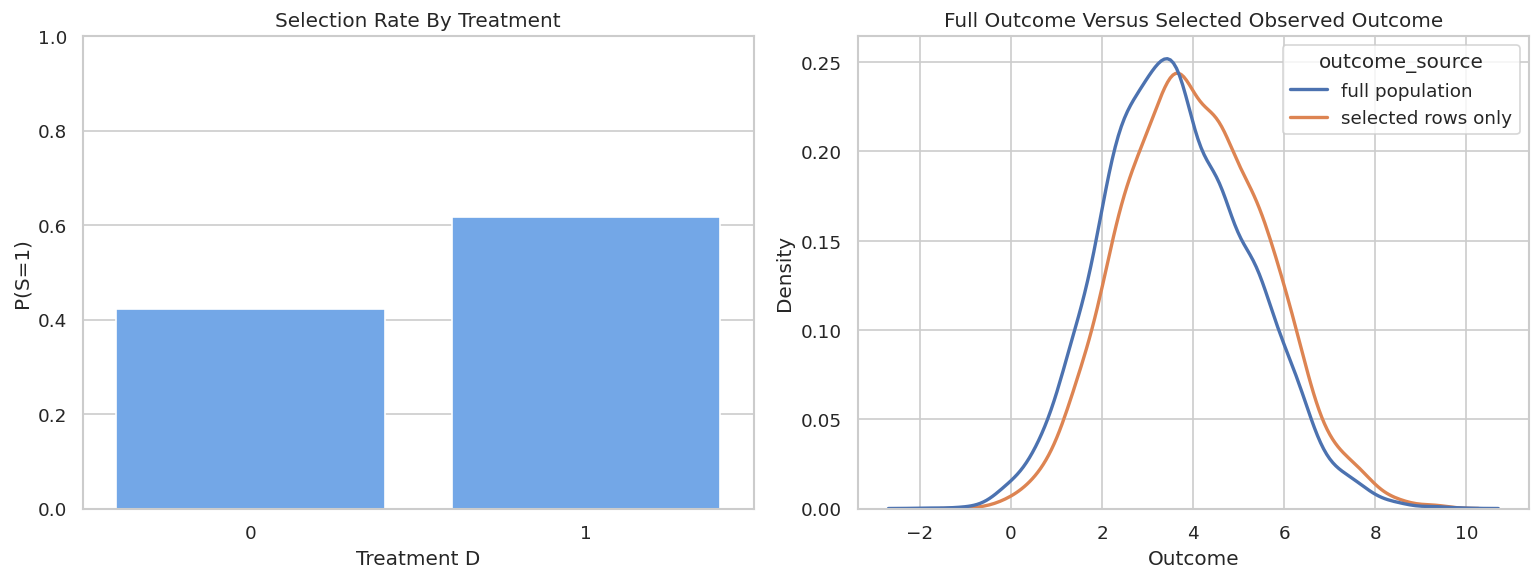

,treated,selected_rate,n
0,0,0.422383,3047
1,1,0.617338,2953


In [6]:
# Build and label the diagnostic visualization for the Selection Rates And Outcome Visibility section.
selection_rate = (
    mar_df.groupby("treated")
    .agg(selected_rate=("selected", "mean"), n=("selected", "size"))
    .reset_index()
)

plot_outcomes = pd.concat(
    [
        mar_df.assign(outcome_source="full population", outcome_for_plot=mar_df["full_outcome"]),
        mar_df.loc[mar_df["selected"] == 1].assign(
            outcome_source="selected rows only",
            outcome_for_plot=mar_df.loc[mar_df["selected"] == 1, "outcome_observed"],
        ),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=selection_rate, x="treated", y="selected_rate", color="#60a5fa", ax=axes[0])
axes[0].set_title("Selection Rate By Treatment")
axes[0].set_xlabel("Treatment D")
axes[0].set_ylabel("P(S=1)")
axes[0].set_ylim(0, 1)

sns.kdeplot(
    data=plot_outcomes,
    x="outcome_for_plot",
    hue="outcome_source",
    common_norm=False,
    linewidth=2,
    ax=axes[1],
)
axes[1].set_title("Full Outcome Versus Selected Observed Outcome")
axes[1].set_xlabel("Outcome")
axes[1].set_ylabel("Density")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_mar_selection_and_outcome_visibility.png", dpi=160, bbox_inches="tight")
plt.show()

display(selection_rate)


Treatment affects selection, and selected rows have a shifted outcome distribution. A selected-row-only analysis is therefore risky because it changes the population being analyzed.



#### Covariate Balance and Selection Balance

Selection can distort the covariate distribution. The table below compares selected and unselected rows on observed features. Large differences make the selection model more important, even when correction may still be possible.

In [7]:
balance_rows = []
for col in feature_cols_mar:
    selected_mean = mar_df.loc[mar_df["selected"] == 1, col].mean()
    unselected_mean = mar_df.loc[mar_df["selected"] == 0, col].mean()
    pooled_sd = mar_df[col].std(ddof=1)
    balance_rows.append(
        {
            "feature": col,
            "selected_mean": selected_mean,
            "unselected_mean": unselected_mean,
            "difference": selected_mean - unselected_mean,
            "standardized_difference": (selected_mean - unselected_mean) / pooled_sd,
        }
    )

selection_balance = pd.DataFrame(balance_rows).sort_values("standardized_difference", key=np.abs, ascending=False)
save_table(selection_balance, f"{NOTEBOOK_PREFIX}_mar_selection_covariate_balance.csv")
display(selection_balance)


,feature,selected_mean,unselected_mean,difference,standardized_difference
5,selection_encouragement,0.279948,-0.288673,0.568620,0.567095
2,support_need,-0.208256,0.262695,-0.470952,-0.470948
0,engagement_score,0.198322,-0.230804,0.429127,0.427795
3,prior_usage,0.109263,-0.048825,0.158088,0.158684
1,baseline_value,-0.010164,-0.020088,0.009924,0.009853
4,mobile_user,0.483280,0.479585,0.003695,0.007394


The selected sample is not a random slice of the full sample. The encouragement and support-need variables are especially important for modeling selection.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->




#### Naive Baselines

The first baseline uses only selected rows and compares treated versus control outcomes. The second baseline uses the synthetic full outcome and is shown only for learning. In real selected-outcome data, the second baseline cannot be computed.

In [8]:
# Fit or evaluate the model objects used in the Naive Baselines section.
selected_df = mar_df.loc[mar_df["selected"] == 1].copy()

naive_selected_diff = (
    selected_df.loc[selected_df["treated"] == 1, "outcome_observed"].mean()
    - selected_df.loc[selected_df["treated"] == 0, "outcome_observed"].mean()
)
full_population_diff = (
    mar_df.loc[mar_df["treated"] == 1, "full_outcome"].mean()
    - mar_df.loc[mar_df["treated"] == 0, "full_outcome"].mean()
)

selected_ols = smf.ols(
    formula="outcome_observed ~ treated + " + " + ".join(feature_cols_mar),
    data=selected_df,
).fit(cov_type="HC3")

baseline_summary = pd.DataFrame(
    [
        {
            "estimator": "Selected-row treated-control difference",
            "theta_hat": naive_selected_diff,
            "std_error": np.nan,
            "ci_95_lower": np.nan,
            "ci_95_upper": np.nan,
            "true_target": TRUE_MAR_ATE,
            "bias_vs_target": naive_selected_diff - TRUE_MAR_ATE,
        },
        {
            "estimator": "Synthetic full-population treated-control difference",
            "theta_hat": full_population_diff,
            "std_error": np.nan,
            "ci_95_lower": np.nan,
            "ci_95_upper": np.nan,
            "true_target": TRUE_MAR_ATE,
            "bias_vs_target": full_population_diff - TRUE_MAR_ATE,
        },
        {
            "estimator": "Selected-row OLS with covariates",
            "theta_hat": float(selected_ols.params["treated"]),
            "std_error": float(selected_ols.bse["treated"]),
            "ci_95_lower": float(selected_ols.conf_int().loc["treated", 0]),
            "ci_95_upper": float(selected_ols.conf_int().loc["treated", 1]),
            "true_target": TRUE_MAR_ATE,
            "bias_vs_target": float(selected_ols.params["treated"] - TRUE_MAR_ATE),
        },
    ]
)
save_table(baseline_summary, f"{NOTEBOOK_PREFIX}_mar_baseline_estimates.csv")
display(baseline_summary)


,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,Selected-row treated-control difference,1.675867,NaN,NaN,NaN,1.032326,0.643540
1,Synthetic full-population treated-control difference,1.732946,NaN,NaN,NaN,1.032326,0.700620
2,Selected-row OLS with covariates,1.065852,0.026952,1.013027,1.118678,1.032326,0.033526


The selected-row difference is far from the true ATE because it mixes treatment assignment, treatment heterogeneity, and outcome observation. Covariate adjustment helps, but it still does not explicitly model the missing-outcome process for the full target population.



#### Manual Cross-Fitted MAR Score

Before fitting `DoubleMLSSM`, we compute a small manual missing-at-random score. This makes the mechanics visible.

The code trains:

- `g(1, X)` on selected treated rows;
- `g(0, X)` on selected control rows;
- `pi(D, X)` on all rows to predict selection;
- `m(X)` on all rows to predict treatment.

Then it combines residualized observed outcomes with outcome-model predictions.

In [9]:
# Define reusable helpers for the Manual Cross-Fitted MAR Score section.
def crossfit_mar_ssm(df, y_col, d_col, s_col, x_cols, ml_g, ml_pi, ml_m, n_splits=5, seed=RANDOM_SEED):
    """
    Idea: Cross-fit the nuisance models for the crossfit missing-at-random sample-selection model design so evaluation uses out-of-fold predictions.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    y_col : str
        Name of the outcome column.
    d_col : str
        Name of the treatment column.
    s_col : object
        Column containing the sample-selection indicator.
    x_cols : list[str]
        Covariate column names used as model inputs.
    ml_g : object
        Outcome-regression learner used by the DoubleML score.
    ml_pi : object
        Learner used to estimate the selection or treatment probability.
    ml_m : object
        Treatment or propensity nuisance learner used by the DoubleML estimator.
    n_splits : object
        Number of folds or sample splits used for cross-fitting.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple[dict, pd.DataFrame]
        Sample-selection effect summary and fold-level nuisance diagnostics.
    """
    X = df[x_cols].reset_index(drop=True)
    y = df[y_col].to_numpy()
    d = df[d_col].to_numpy()
    s = df[s_col].to_numpy()
    dx = pd.concat([X, pd.Series(d, name=d_col)], axis=1)
    n = len(df)

    g1_hat = np.full(n, np.nan)
    g0_hat = np.full(n, np.nan)
    pi_hat = np.full(n, np.nan)
    m_hat = np.full(n, np.nan)

    strata = d + 2 * s
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for train_idx, test_idx in splitter.split(X, strata):
        train_selected_treated = train_idx[(s[train_idx] == 1) & (d[train_idx] == 1)]
        train_selected_control = train_idx[(s[train_idx] == 1) & (d[train_idx] == 0)]

        g1_model = clone(ml_g)
        g0_model = clone(ml_g)
        pi_model = clone(ml_pi)
        m_model = clone(ml_m)

        g1_model.fit(X.iloc[train_selected_treated], y[train_selected_treated])
        g0_model.fit(X.iloc[train_selected_control], y[train_selected_control])
        pi_model.fit(dx.iloc[train_idx], s[train_idx])
        m_model.fit(X.iloc[train_idx], d[train_idx])

        g1_hat[test_idx] = g1_model.predict(X.iloc[test_idx])
        g0_hat[test_idx] = g0_model.predict(X.iloc[test_idx])
        pi_hat[test_idx] = predict_probability(pi_model, dx.iloc[test_idx])
        m_hat[test_idx] = predict_probability(m_model, X.iloc[test_idx])

    pi_hat = clip_probability(pi_hat)
    m_hat = clip_probability(m_hat)

    treated_contribution = d * s * (y - g1_hat) / (m_hat * pi_hat) + g1_hat
    control_contribution = (1 - d) * s * (y - g0_hat) / ((1 - m_hat) * pi_hat) + g0_hat
    score_contribution = treated_contribution - control_contribution

    theta_hat = score_contribution.mean()
    std_error = score_contribution.std(ddof=1) / np.sqrt(n)

    summary = pd.DataFrame(
        [
            {
                "estimator": "Manual cross-fitted MAR SSM",
                "theta_hat": theta_hat,
                "std_error": std_error,
                "ci_95_lower": theta_hat - 1.96 * std_error,
                "ci_95_upper": theta_hat + 1.96 * std_error,
                "true_target": TRUE_MAR_ATE,
                "bias_vs_target": theta_hat - TRUE_MAR_ATE,
            }
        ]
    )
    diagnostics = pd.DataFrame(
        {
            "g1_hat": g1_hat,
            "g0_hat": g0_hat,
            "pi_hat": pi_hat,
            "m_hat": m_hat,
            "score_contribution": score_contribution,
            "treated": d,
            "selected": s,
        }
    )
    return summary, diagnostics

linear_g, linear_pi, linear_m = make_linear_learners()
manual_mar_summary, manual_mar_diagnostics = crossfit_mar_ssm(
    mar_df,
    y_col="outcome_observed",
    d_col="treated",
    s_col="selected",
    x_cols=feature_cols_mar,
    ml_g=linear_g,
    ml_pi=linear_pi,
    ml_m=linear_m,
    n_splits=5,
    seed=RANDOM_SEED,
)
save_table(manual_mar_summary, f"{NOTEBOOK_PREFIX}_manual_mar_ssm_summary.csv")
save_table(manual_mar_diagnostics.describe().reset_index(), f"{NOTEBOOK_PREFIX}_manual_mar_ssm_diagnostics.csv")
display(manual_mar_summary)


,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,Manual cross-fitted MAR SSM,1.003513,0.030544,0.943647,1.06338,1.032326,-0.028813


The manual score is much closer to the true ATE than the selected-row difference. That is the core lesson: selection correction uses unselected rows through the selection and treatment models, even though their outcomes are not observed.

#### Manual Score Diagnostics

The manual diagnostics check whether treatment and selection probabilities are extreme. The score contribution plot shows whether a few rows dominate the estimate.

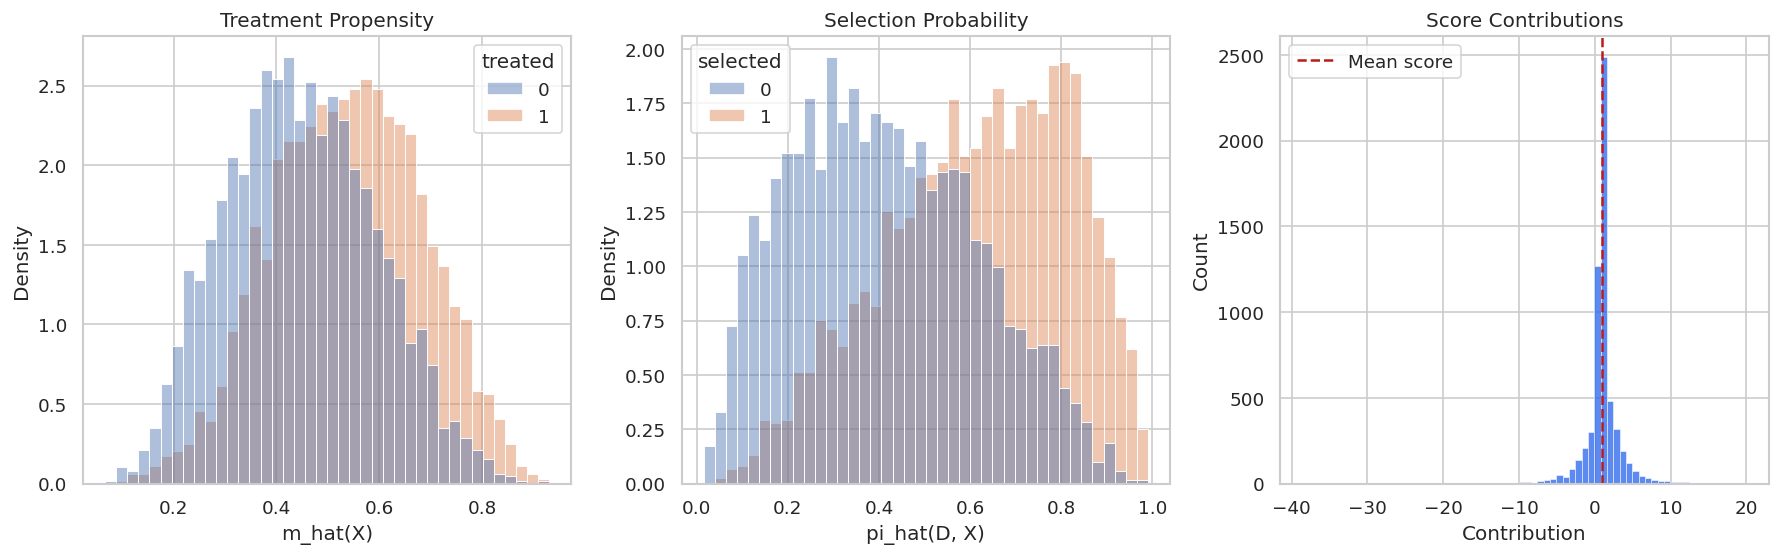

In [10]:
# Build and label the diagnostic visualization for the Manual Score Diagnostics section.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

sns.histplot(
    data=manual_mar_diagnostics,
    x="m_hat",
    hue="treated",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_title("Treatment Propensity")
axes[0].set_xlabel("m_hat(X)")
axes[0].set_ylabel("Density")

sns.histplot(
    data=manual_mar_diagnostics,
    x="pi_hat",
    hue="selected",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=axes[1],
)
axes[1].set_title("Selection Probability")
axes[1].set_xlabel("pi_hat(D, X)")
axes[1].set_ylabel("Density")

sns.histplot(
    data=manual_mar_diagnostics,
    x="score_contribution",
    bins=70,
    color="#2563eb",
    ax=axes[2],
)
axes[2].axvline(manual_mar_summary["theta_hat"].iloc[0], color="#b91c1c", linestyle="--", label="Mean score")
axes[2].set_title("Score Contributions")
axes[2].set_xlabel("Contribution")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_manual_mar_score_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()


The treatment and selection predictions are mostly away from 0 and 1. That matters because inverse-probability terms become unstable when predicted probabilities are too small.

The figure matters because it turns the numeric output into a pattern that can be inspected before trusting the next modeling step.
<!-- result-implication-expanded -->




#### DoubleML Sample-Selection Backend

`DoubleMLSSMData` is the data contract for sample-selection models. The selection column is passed as `s_col`. Unselected rows stay in the data because they are needed for the treatment and selection nuisance models.

In [11]:
mar_dml_data = DoubleMLSSMData(
    mar_df,
    y_col="outcome_observed",
    d_cols="treated",
    s_col="selected",
    x_cols=feature_cols_mar,
)

mar_backend_summary = pd.DataFrame(
    [
        {"property": "n_obs", "value": mar_dml_data.n_obs},
        {"property": "outcome", "value": mar_dml_data.y_col},
        {"property": "treatment", "value": ", ".join(mar_dml_data.d_cols)},
        {"property": "selection", "value": mar_dml_data.s_col},
        {"property": "n_covariates", "value": len(mar_dml_data.x_cols)},
        {"property": "covariates", "value": ", ".join(mar_dml_data.x_cols)},
    ]
)
save_table(mar_backend_summary, f"{NOTEBOOK_PREFIX}_mar_doublemlssm_backend.csv")
display(mar_backend_summary)


,property,value
0,n_obs,6000
1,outcome,outcome_observed
2,treatment,treated
3,selection,selected
4,n_covariates,6
5,covariates,"engagement_score, baseline_value, support_need, prior_usage, mobile_user, selection_encouragement"


This is the most important API cell in the notebook. If `s_col` is missing, the model no longer knows which outcomes are observed and the selected-outcome design is lost.



#### Fit `DoubleMLSSM` Under Missing at Random

We fit three versions:

- linear nuisance learners;
- gradient boosting nuisance learners;
- gradient boosting with normalized inverse-probability weights.

The normalized version can be helpful when weights are noisy, but it is not a magic fix for poor overlap or wrong assumptions.

In [12]:
# Fit or evaluate the model objects used in the Fit `DoubleMLSSM` Under Missing At Random section.
mar_model_rows = []
mar_models = {}

ml_g_linear, ml_pi_linear, ml_m_linear = make_linear_learners()
mar_ssm_linear = DoubleMLSSM(
    mar_dml_data,
    ml_g=ml_g_linear,
    ml_pi=ml_pi_linear,
    ml_m=ml_m_linear,
    n_folds=5,
    score="missing-at-random",
)
mar_ssm_linear.fit(store_predictions=True)
mar_models["MAR linear"] = mar_ssm_linear
mar_model_rows.append(summarize_doubleml(mar_ssm_linear, "MAR linear", "missing-at-random", TRUE_MAR_ATE))

ml_g_hgb, ml_pi_hgb, ml_m_hgb = make_hgb_learners(seed=RANDOM_SEED + 10, max_iter=90)
mar_ssm_hgb = DoubleMLSSM(
    mar_dml_data,
    ml_g=ml_g_hgb,
    ml_pi=ml_pi_hgb,
    ml_m=ml_m_hgb,
    n_folds=5,
    score="missing-at-random",
)
mar_ssm_hgb.fit(store_predictions=True)
mar_models["MAR HGB"] = mar_ssm_hgb
mar_model_rows.append(summarize_doubleml(mar_ssm_hgb, "MAR HGB", "missing-at-random", TRUE_MAR_ATE))

ml_g_norm, ml_pi_norm, ml_m_norm = make_hgb_learners(seed=RANDOM_SEED + 20, max_iter=90)
mar_ssm_hgb_norm = DoubleMLSSM(
    mar_dml_data,
    ml_g=ml_g_norm,
    ml_pi=ml_pi_norm,
    ml_m=ml_m_norm,
    n_folds=5,
    score="missing-at-random",
    normalize_ipw=True,
)
mar_ssm_hgb_norm.fit(store_predictions=True)
mar_models["MAR HGB normalized IPW"] = mar_ssm_hgb_norm
mar_model_rows.append(summarize_doubleml(mar_ssm_hgb_norm, "MAR HGB normalized IPW", "missing-at-random", TRUE_MAR_ATE))

mar_doubleml_summary = pd.DataFrame(mar_model_rows)
save_table(mar_doubleml_summary, f"{NOTEBOOK_PREFIX}_mar_doublemlssm_summary.csv")
display(mar_doubleml_summary)


,estimator,design,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,MAR linear,missing-at-random,1.003229,0.030373,0.943700,1.062758,1.032326,-0.029098
1,MAR HGB,missing-at-random,0.987377,0.036071,0.916678,1.058076,1.032326,-0.044949
2,MAR HGB normalized IPW,missing-at-random,1.020675,0.017833,0.985723,1.055626,1.032326,-0.011652


The DoubleML estimates are close to the true full-population ATE. The selected-row difference was much larger, which shows why the selection problem matters.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Estimate Comparison

The comparison plot puts the naive baselines, manual score, and DoubleML estimates on one axis. This is often the clearest way to communicate what selection correction changed.

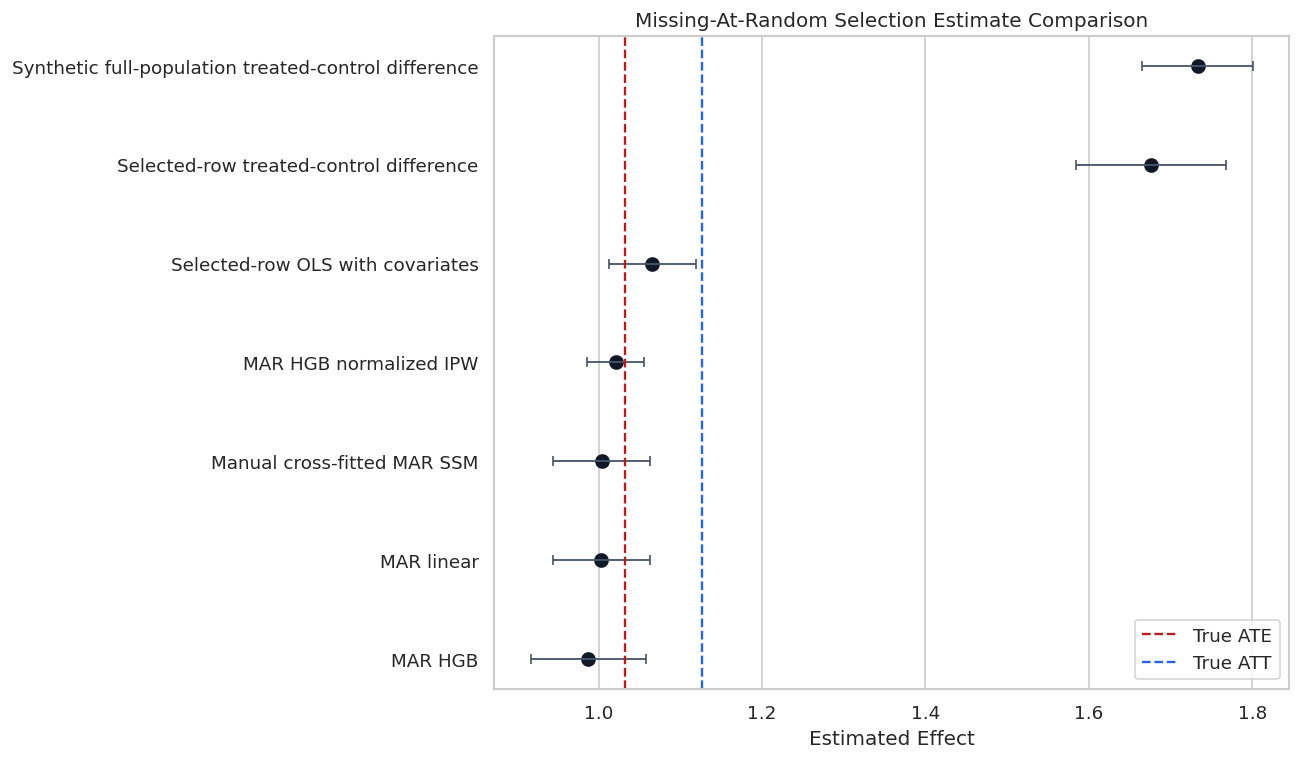

,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target,design
0,Selected-row treated-control difference,1.675867,0.046957,1.583831,1.767903,1.032326,0.643540,NaN
1,Synthetic full-population treated-control difference,1.732946,0.034447,1.665431,1.800462,1.032326,0.700620,NaN
2,Selected-row OLS with covariates,1.065852,0.026952,1.013027,1.118678,1.032326,0.033526,NaN
3,Manual cross-fitted MAR SSM,1.003513,0.030544,0.943647,1.063380,1.032326,-0.028813,NaN
4,MAR linear,1.003229,0.030373,0.943700,1.062758,1.032326,-0.029098,missing-at-random
5,MAR HGB,0.987377,0.036071,0.916678,1.058076,1.032326,-0.044949,missing-at-random
6,MAR HGB normalized IPW,1.020675,0.017833,0.985723,1.055626,1.032326,-0.011652,missing-at-random


In [13]:
# Build and label the diagnostic visualization for the Estimate Comparison section.
mar_estimates = pd.concat(
    [
        baseline_summary,
        manual_mar_summary,
        mar_doubleml_summary,
    ],
    ignore_index=True,
    sort=False,
)

# Add simple intervals for rows without model-based intervals when available.
selected_diff_se = np.sqrt(
    selected_df.loc[selected_df["treated"] == 1, "outcome_observed"].var(ddof=1) / (selected_df["treated"] == 1).sum()
    + selected_df.loc[selected_df["treated"] == 0, "outcome_observed"].var(ddof=1) / (selected_df["treated"] == 0).sum()
)
mar_estimates.loc[mar_estimates["estimator"] == "Selected-row treated-control difference", "std_error"] = selected_diff_se
mar_estimates.loc[mar_estimates["estimator"] == "Selected-row treated-control difference", "ci_95_lower"] = naive_selected_diff - 1.96 * selected_diff_se
mar_estimates.loc[mar_estimates["estimator"] == "Selected-row treated-control difference", "ci_95_upper"] = naive_selected_diff + 1.96 * selected_diff_se

full_diff_se = np.sqrt(
    mar_df.loc[mar_df["treated"] == 1, "full_outcome"].var(ddof=1) / (mar_df["treated"] == 1).sum()
    + mar_df.loc[mar_df["treated"] == 0, "full_outcome"].var(ddof=1) / (mar_df["treated"] == 0).sum()
)
mar_estimates.loc[mar_estimates["estimator"] == "Synthetic full-population treated-control difference", "std_error"] = full_diff_se
mar_estimates.loc[mar_estimates["estimator"] == "Synthetic full-population treated-control difference", "ci_95_lower"] = full_population_diff - 1.96 * full_diff_se
mar_estimates.loc[mar_estimates["estimator"] == "Synthetic full-population treated-control difference", "ci_95_upper"] = full_population_diff + 1.96 * full_diff_se

save_table(mar_estimates, f"{NOTEBOOK_PREFIX}_mar_estimate_comparison.csv")
plot_mar_estimates = add_ci_columns(mar_estimates)

fig, ax = plt.subplots(figsize=(11, 6.5))
order = plot_mar_estimates.sort_values("theta_hat", ascending=False)["estimator"]
sns.pointplot(
    data=plot_mar_estimates,
    y="estimator",
    x="theta_hat",
    order=order,
    linestyle="none",
    color="#111827",
    errorbar=None,
    ax=ax,
)
for y_pos, (_, row) in enumerate(plot_mar_estimates.set_index("estimator").loc[order].reset_index().iterrows()):
    ax.errorbar(
        x=row["theta_hat"],
        y=y_pos,
        xerr=[[row["lower_error"]], [row["upper_error"]]],
        fmt="none",
        color="#475569",
        capsize=3,
        linewidth=1.1,
    )
ax.axvline(TRUE_MAR_ATE, color="#b91c1c", linestyle="--", linewidth=1.4, label="True ATE")
ax.axvline(TRUE_MAR_ATT, color="#2563eb", linestyle="--", linewidth=1.4, label="True ATT")
ax.set_title("Missing-At-Random Selection Estimate Comparison")
ax.set_xlabel("Estimated Effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_mar_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

display(mar_estimates)


The corrected estimates move toward the full-population ATE. The plot also shows that the ATT is a different target; selected-outcome correction does not remove the need to state the estimand.

### Nuisance Learner Diagnostics

Now we inspect the nuisance learners. These diagnostics are not a proof of selection validity. They are checks that the prediction components are not obviously broken.

In [14]:
mar_loss_tables = []
for label, model in mar_models.items():
    mar_loss_tables.append(learner_loss_table(model, label))

mar_nuisance_losses = pd.concat(mar_loss_tables, ignore_index=True)
save_table(mar_nuisance_losses, f"{NOTEBOOK_PREFIX}_mar_nuisance_losses.csv")
display(mar_nuisance_losses)

,model,learner,metric_value,metric
0,MAR linear,ml_g_d0,2.237299,RMSE for outcome learners; classification error style score for propensity learners
1,MAR linear,ml_g_d1,2.838365,RMSE for outcome learners; classification error style score for propensity learners
2,MAR linear,ml_pi,0.446221,RMSE for outcome learners; classification error style score for propensity learners
3,MAR linear,ml_m,0.477182,RMSE for outcome learners; classification error style score for propensity learners
4,MAR HGB,ml_g_d0,2.252666,RMSE for outcome learners; classification error style score for propensity learners
5,MAR HGB,ml_g_d1,2.859072,RMSE for outcome learners; classification error style score for propensity learners
6,MAR HGB,ml_pi,0.450343,RMSE for outcome learners; classification error style score for propensity learners
7,MAR HGB,ml_m,0.479655,RMSE for outcome learners; classification error style score for propensity learners
8,MAR HGB normalized IPW,ml_g_d0,2.252788,RMSE for outcome learners; classification error style score for propensity learners
9,MAR HGB normalized IPW,ml_g_d1,2.864428,RMSE for outcome learners; classification error style score for propensity learners


The outcome nuisance losses are measured on the outcome scale. The propensity learner losses summarize classification-style performance. If these losses were very poor, the final estimate would deserve more skepticism.



### Prediction Quality Against Synthetic Truth

Because the data are synthetic, we can compare the HGB nuisance predictions to true treatment and selection probabilities. In real data, this truth is unavailable, but the same plots can still reveal extreme probabilities.

In [15]:
# Save the artifacts produced by the Prediction Quality Against Synthetic Truth section.
mar_hgb_predictions = pd.DataFrame(
    {
        "treated": mar_df["treated"],
        "selected": mar_df["selected"],
        "true_treatment_propensity": mar_df["true_treatment_propensity"],
        "true_selection_probability": mar_df["true_selection_probability"],
        "m_hat": prediction_vector(mar_ssm_hgb, "ml_m"),
        "pi_hat": prediction_vector(mar_ssm_hgb, "ml_pi"),
        "g0_hat": prediction_vector(mar_ssm_hgb, "ml_g_d0"),
        "g1_hat": prediction_vector(mar_ssm_hgb, "ml_g_d1"),
        "full_outcome": mar_df["full_outcome"],
        "true_tau": mar_df["true_tau"],
    }
)

mar_prediction_quality = pd.DataFrame(
    [
        {
            "quantity": "treatment propensity m_hat",
            "rmse_vs_truth": rmse(mar_hgb_predictions["true_treatment_propensity"], mar_hgb_predictions["m_hat"]),
            "mae_vs_truth": mean_absolute_error(mar_hgb_predictions["true_treatment_propensity"], mar_hgb_predictions["m_hat"]),
        },
        {
            "quantity": "selection probability pi_hat",
            "rmse_vs_truth": rmse(mar_hgb_predictions["true_selection_probability"], mar_hgb_predictions["pi_hat"]),
            "mae_vs_truth": mean_absolute_error(mar_hgb_predictions["true_selection_probability"], mar_hgb_predictions["pi_hat"]),
        },
    ]
)
save_table(mar_prediction_quality, f"{NOTEBOOK_PREFIX}_mar_hgb_prediction_quality.csv")
display(mar_prediction_quality)


,quantity,rmse_vs_truth,mae_vs_truth
0,treatment propensity m_hat,0.069900,0.054594
1,selection probability pi_hat,0.074019,0.056835


The probability predictions track the synthetic truth reasonably well. This confirms that the nuisance models are learning the intended observed structure, while the causal guarantee still depends on the design.



#### Treatment and Selection Overlap

The next plot is one of the most important diagnostics in a sample-selection analysis. Both the treatment propensity and the selection probability appear in denominators. Near-zero probabilities can create unstable weights.

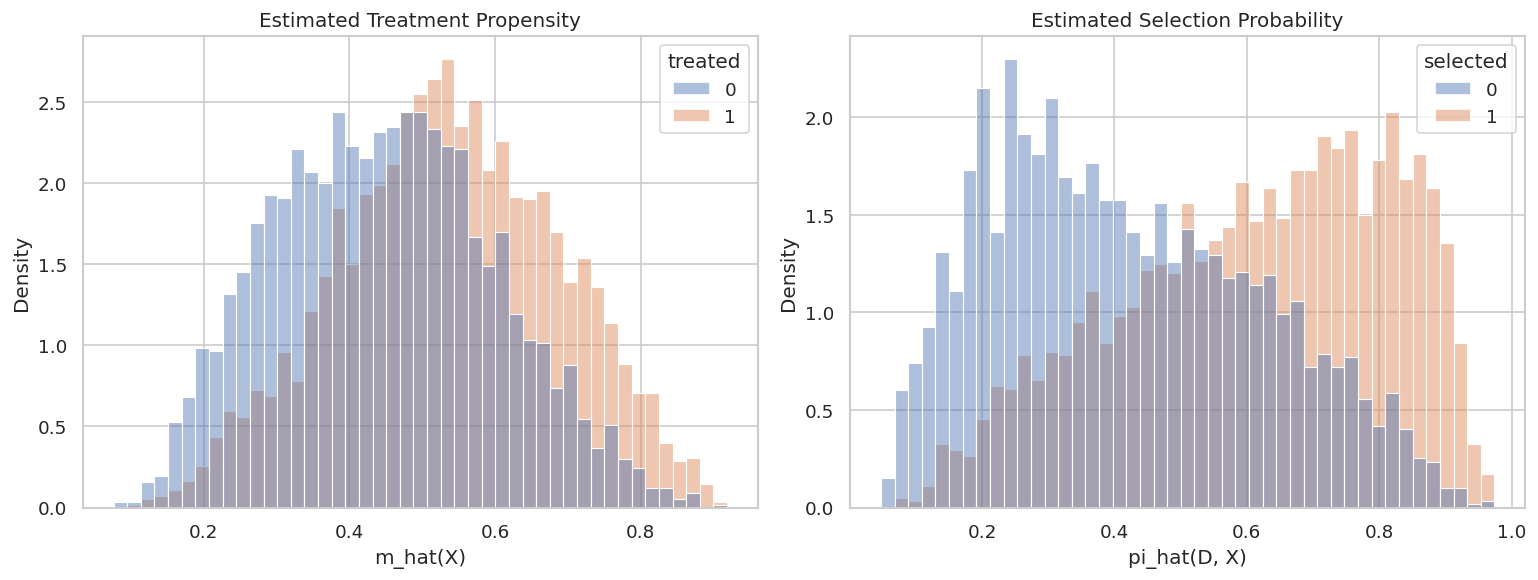

In [16]:
# Build and label the diagnostic visualization for the Treatment And Selection Overlap section.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=mar_hgb_predictions,
    x="m_hat",
    hue="treated",
    bins=45,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_title("Estimated Treatment Propensity")
axes[0].set_xlabel("m_hat(X)")
axes[0].set_ylabel("Density")

sns.histplot(
    data=mar_hgb_predictions,
    x="pi_hat",
    hue="selected",
    bins=45,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=axes[1],
)
axes[1].set_title("Estimated Selection Probability")
axes[1].set_xlabel("pi_hat(D, X)")
axes[1].set_ylabel("Density")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_mar_overlap_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()


The predicted probabilities have usable overlap and are not concentrated at the clipping boundaries. That is a good sign for this synthetic example.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->


#### Bootstrap Confidence Interval

The multiplier bootstrap gives another uncertainty view for the preferred MAR model. It quantifies sampling uncertainty under the maintained design assumptions.

In [17]:
mar_ssm_hgb.bootstrap(method="normal", n_rep_boot=500)
mar_bootstrap_ci = mar_ssm_hgb.confint(level=0.95).reset_index().rename(columns={"index": "treatment"})
mar_bootstrap_ci["estimator"] = "MAR HGB bootstrap CI"
save_table(mar_bootstrap_ci, f"{NOTEBOOK_PREFIX}_mar_hgb_bootstrap_ci.csv")
display(mar_bootstrap_ci)

,treatment,2.5 %,97.5 %,estimator
0,treated,0.916678,1.058076,MAR HGB bootstrap CI


The bootstrap interval should be reported alongside the point estimate, but it does not account for misspecified selection assumptions. Selection bias is a design concern, more than a sampling concern.

#### Selection Positivity Stress Test

This stress test shifts the selection equation so outcomes become easier or harder to observe. Lower selection rates usually increase uncertainty because fewer outcomes are available for the outcome regressions and inverse-selection correction.

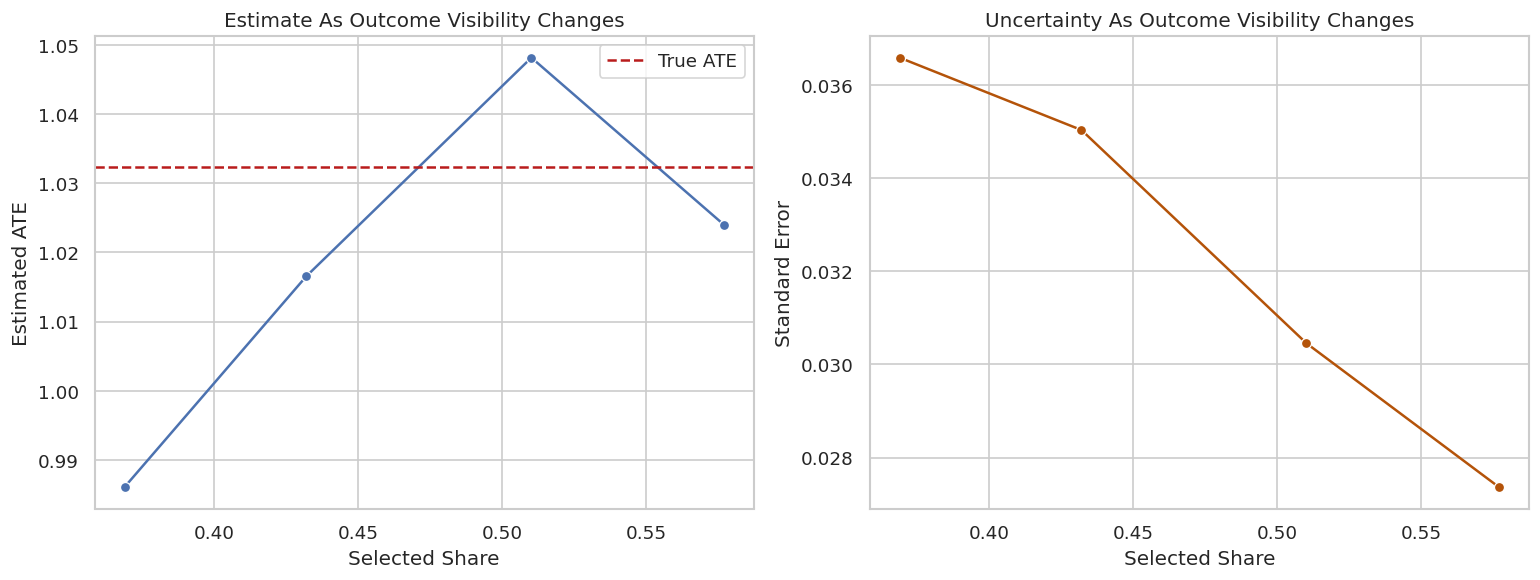

,selection_shift,selected_share,theta_hat,std_error,true_target,bias_vs_target
0,-0.70,0.368833,0.986103,0.036594,1.032326,-0.046223
1,-0.35,0.432000,1.016577,0.035038,1.032326,-0.015750
2,0.00,0.510167,1.048153,0.030455,1.032326,0.015827
3,0.35,0.577000,1.024028,0.027366,1.032326,-0.008298


In [18]:
# Build and label the diagnostic visualization for the Selection Positivity Stress Test section.
stress_rows = []
for selection_shift in [-0.70, -0.35, 0.00, 0.35]:
    stress_probability = sigmoid(
        selection_shift
        - 0.25
        + 0.55 * mar_df["treated"]
        + 0.45 * mar_df["engagement_score"]
        - 0.55 * mar_df["support_need"]
        + 0.25 * mar_df["prior_usage"]
        + 0.70 * mar_df["selection_encouragement"]
    )
    stress_selected = rng.binomial(1, stress_probability)
    stress_df = mar_df.copy()
    stress_df["selected_stress"] = stress_selected
    stress_df["outcome_stress"] = stress_df["full_outcome"]
    stress_df.loc[stress_df["selected_stress"] == 0, "outcome_stress"] = 0.0

    stress_data = DoubleMLSSMData(
        stress_df,
        y_col="outcome_stress",
        d_cols="treated",
        s_col="selected_stress",
        x_cols=feature_cols_mar,
    )
    ml_g_stress, ml_pi_stress, ml_m_stress = make_linear_learners()
    stress_model = DoubleMLSSM(
        stress_data,
        ml_g=ml_g_stress,
        ml_pi=ml_pi_stress,
        ml_m=ml_m_stress,
        n_folds=5,
        score="missing-at-random",
    )
    stress_model.fit(store_predictions=False)
    stress_rows.append(
        {
            "selection_shift": selection_shift,
            "selected_share": stress_selected.mean(),
            "theta_hat": float(stress_model.coef[0]),
            "std_error": float(stress_model.se[0]),
            "true_target": TRUE_MAR_ATE,
            "bias_vs_target": float(stress_model.coef[0] - TRUE_MAR_ATE),
        }
    )

selection_stress = pd.DataFrame(stress_rows)
save_table(selection_stress, f"{NOTEBOOK_PREFIX}_selection_positivity_stress.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(data=selection_stress, x="selected_share", y="theta_hat", marker="o", ax=axes[0])
axes[0].axhline(TRUE_MAR_ATE, color="#b91c1c", linestyle="--", label="True ATE")
axes[0].set_title("Estimate As Outcome Visibility Changes")
axes[0].set_xlabel("Selected Share")
axes[0].set_ylabel("Estimated ATE")
axes[0].legend()

sns.lineplot(data=selection_stress, x="selected_share", y="std_error", marker="o", color="#b45309", ax=axes[1])
axes[1].set_title("Uncertainty As Outcome Visibility Changes")
axes[1].set_xlabel("Selected Share")
axes[1].set_ylabel("Standard Error")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_selection_positivity_stress.png", dpi=160, bbox_inches="tight")
plt.show()

display(selection_stress)


The standard error tends to rise when fewer outcomes are observed. This is the practical cost of selected outcomes: even when the assumptions are correct, less outcome visibility means less information.



#### Nonignorable Selection Data

The next dataset adds a hidden response factor `U`. This hidden factor affects both outcome observation and the outcome itself. A missing-at-random analysis is now misspecified because conditioning on observed covariates is not enough.

We also add `selection_encouragement`, a variable that affects selection but does not directly affect the outcome. In the synthetic design, this variable satisfies the exclusion restriction. In real work, that restriction would require a domain argument.

In [19]:
# Save the artifacts produced by the Nonignorable Selection Data section.
rng_non = np.random.default_rng(RANDOM_SEED + 100)
N_NON = 6_000

non_engagement = rng_non.normal(0, 1, N_NON)
non_baseline = rng_non.normal(0, 1, N_NON)
non_support = rng_non.normal(0, 1, N_NON)
non_prior_usage = rng_non.normal(0, 1, N_NON)
non_mobile = rng_non.binomial(1, 0.48, N_NON)
non_selection_encouragement = rng_non.normal(0, 1, N_NON)
hidden_response_factor = rng_non.normal(0, 1, N_NON)

non_x = pd.DataFrame(
    {
        "engagement_score": non_engagement,
        "baseline_value": non_baseline,
        "support_need": non_support,
        "prior_usage": non_prior_usage,
        "mobile_user": non_mobile,
    }
)
feature_cols_non = list(non_x.columns)

non_treatment_propensity = sigmoid(-0.10 + 0.55 * non_engagement + 0.35 * non_baseline - 0.30 * non_support + 0.18 * non_mobile)
non_treated = rng_non.binomial(1, non_treatment_propensity)
non_tau = 1.00 + 0.25 * non_engagement + 0.15 * non_baseline - 0.10 * non_support + 0.08 * non_mobile
non_mu0 = 3.00 + 0.80 * non_engagement + 0.50 * non_baseline - 0.30 * non_support + 0.25 * non_prior_usage + 0.20 * non_mobile
non_full_outcome = non_mu0 + non_tau * non_treated + 0.60 * hidden_response_factor + rng_non.normal(0, 0.55, N_NON)

non_selection_probability = sigmoid(
    -0.25
    + 0.55 * non_treated
    + 0.45 * non_engagement
    - 0.55 * non_support
    + 0.25 * non_prior_usage
    + 0.85 * non_selection_encouragement
    + 0.75 * hidden_response_factor
)
non_selected = rng_non.binomial(1, non_selection_probability)
non_outcome_observed = non_full_outcome.copy()
non_outcome_observed[non_selected == 0] = 0.0

non_df = pd.concat(
    [
        pd.DataFrame({"row_id": np.arange(N_NON)}),
        non_x,
        pd.DataFrame(
            {
                "selection_encouragement": non_selection_encouragement,
                "treated": non_treated,
                "selected": non_selected,
                "outcome_observed": non_outcome_observed,
                "full_outcome": non_full_outcome,
                "true_tau": non_tau,
                "true_treatment_propensity": non_treatment_propensity,
                "true_selection_probability": non_selection_probability,
                "hidden_response_factor": hidden_response_factor,
            }
        ),
    ],
    axis=1,
)

TRUE_NON_ATE = non_df["true_tau"].mean()
non_path = DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_nonignorable_selection_data.csv"
non_df.to_csv(non_path, index=False)

print(f"Rows: {len(non_df):,}")
print(f"Selected share: {non_df['selected'].mean():.3f}")
print(f"True nonignorable-design ATE: {TRUE_NON_ATE:.4f}")
print(f"Saved data to: {non_path.relative_to(PROJECT_ROOT)}")
display(non_df.head())


Rows: 6,000
Selected share: 0.509
True nonignorable-design ATE: 1.0389
Saved data to: notebooks/tutorials/doubleml/outputs/datasets/08_synthetic_nonignorable_selection_data.csv


,row_id,engagement_score,baseline_value,support_need,prior_usage,mobile_user,selection_encouragement,treated,selected,outcome_observed,full_outcome,true_tau,true_treatment_propensity,true_selection_probability,hidden_response_factor
0,0,-0.311445,-0.577787,-0.069680,0.874368,0,-1.616559,0,0,0.000000,1.737582,0.842439,0.388739,0.043021,-2.126387
1,1,-2.245198,0.178591,0.631997,-1.302306,1,-0.500702,0,0,0.000000,1.281574,0.482289,0.217218,0.075842,-0.188155
2,2,-0.214792,-0.104288,0.117372,-0.859742,0,0.019919,1,1,4.283298,4.283298,0.918922,0.428041,0.740645,1.478050
3,3,0.886864,0.208647,0.431936,-0.321071,1,-0.362617,1,1,5.454790,5.454790,1.289819,0.625093,0.550140,0.170938
4,4,0.174338,-0.218863,-0.605183,-0.134723,1,1.157343,1,0,0.000000,4.405956,1.151273,0.569752,0.851009,0.108234


This design deliberately violates missing-at-random selection. The hidden factor affects both selection and the outcome. The selection encouragement is available as an instrument-like variable for the nonignorable score.

#### Nonignorable Design Checks

Before fitting the nonignorable model, check that the selection encouragement is relevant for selection and mechanically unrelated to treatment. In synthetic data, we know it has no direct outcome effect. Applied work would need a real argument.

In [20]:
non_checks = pd.DataFrame(
    [
        {"metric": "selected_share", "value": non_df["selected"].mean()},
        {"metric": "treated_share", "value": non_df["treated"].mean()},
        {"metric": "corr_selection_encouragement_selected", "value": non_df["selection_encouragement"].corr(non_df["selected"])},
        {"metric": "corr_selection_encouragement_treated", "value": non_df["selection_encouragement"].corr(non_df["treated"])},
        {"metric": "corr_hidden_factor_selected", "value": non_df["hidden_response_factor"].corr(non_df["selected"])},
        {"metric": "corr_hidden_factor_full_outcome", "value": non_df["hidden_response_factor"].corr(non_df["full_outcome"])},
    ]
)
save_table(non_checks, f"{NOTEBOOK_PREFIX}_nonignorable_design_checks.csv")
display(non_checks)


,metric,value
0,selected_share,0.509000
1,treated_share,0.512667
2,corr_selection_encouragement_selected,0.300239
3,corr_selection_encouragement_treated,0.018788
4,corr_hidden_factor_selected,0.269843
5,corr_hidden_factor_full_outcome,0.372271


The selection encouragement is relevant for selection. The hidden factor is also related to selection and the outcome, which is why the missing-at-random analysis is no longer conceptually right.



#### MAR versus Nonignorable Scores

Now we fit two models to the nonignorable dataset:

- a missing-at-random score that treats the selection process as observed-covariate explainable;
- a nonignorable score that uses `selection_encouragement` as a selection instrument.

The nonignorable backend passes `selection_encouragement` through `z_cols` instead of treating it as an ordinary covariate.

In [21]:
# Fit or evaluate the model objects used in the MAR Versus Nonignorable Scores section.
non_mar_features = feature_cols_non + ["selection_encouragement"]
non_mar_data = DoubleMLSSMData(
    non_df,
    y_col="outcome_observed",
    d_cols="treated",
    s_col="selected",
    x_cols=non_mar_features,
)
non_iv_data = DoubleMLSSMData(
    non_df,
    y_col="outcome_observed",
    d_cols="treated",
    s_col="selected",
    x_cols=feature_cols_non,
    z_cols="selection_encouragement",
)

non_rows = []

non_mar_g, non_mar_pi, non_mar_m = make_linear_learners()
wrong_mar_model = DoubleMLSSM(
    non_mar_data,
    ml_g=non_mar_g,
    ml_pi=non_mar_pi,
    ml_m=non_mar_m,
    n_folds=5,
    score="missing-at-random",
)
wrong_mar_model.fit(store_predictions=True)
non_rows.append(summarize_doubleml(wrong_mar_model, "MAR score on nonignorable data", "nonignorable data", TRUE_NON_ATE))

non_g, non_pi, non_m = make_linear_learners()
nonignorable_model = DoubleMLSSM(
    non_iv_data,
    ml_g=non_g,
    ml_pi=non_pi,
    ml_m=non_m,
    n_folds=5,
    score="nonignorable",
)
nonignorable_model.fit(store_predictions=True)
non_rows.append(summarize_doubleml(nonignorable_model, "Nonignorable score with selection instrument", "nonignorable data", TRUE_NON_ATE))

non_hgb_g, non_hgb_pi, non_hgb_m = make_hgb_learners(seed=RANDOM_SEED + 60, max_iter=70)
nonignorable_hgb = DoubleMLSSM(
    non_iv_data,
    ml_g=non_hgb_g,
    ml_pi=non_hgb_pi,
    ml_m=non_hgb_m,
    n_folds=5,
    score="nonignorable",
)
nonignorable_hgb.fit(store_predictions=True)
non_rows.append(summarize_doubleml(nonignorable_hgb, "Nonignorable score HGB", "nonignorable data", TRUE_NON_ATE))

nonignorable_summary = pd.DataFrame(non_rows)
save_table(nonignorable_summary, f"{NOTEBOOK_PREFIX}_nonignorable_score_comparison.csv")
display(nonignorable_summary)


,estimator,design,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,MAR score on nonignorable data,nonignorable data,1.028351,0.035555,0.958665,1.098037,1.038926,-0.010575
1,Nonignorable score with selection instrument,nonignorable data,1.067830,0.041649,0.986200,1.149460,1.038926,0.028904
2,Nonignorable score HGB,nonignorable data,1.085624,0.056173,0.975527,1.195721,1.038926,0.046698


The nonignorable score uses extra structure to address a hidden selection path. The improvement is not automatic in every sample, and it depends on the selection encouragement being a credible exclusion variable.



#### Nonignorable Estimate Plot

The plot below keeps the nonignorable comparison separate from the missing-at-random dataset because the data-generating process is different. The point is not to crown a universal best model; it is to show that the score must match the selection story.

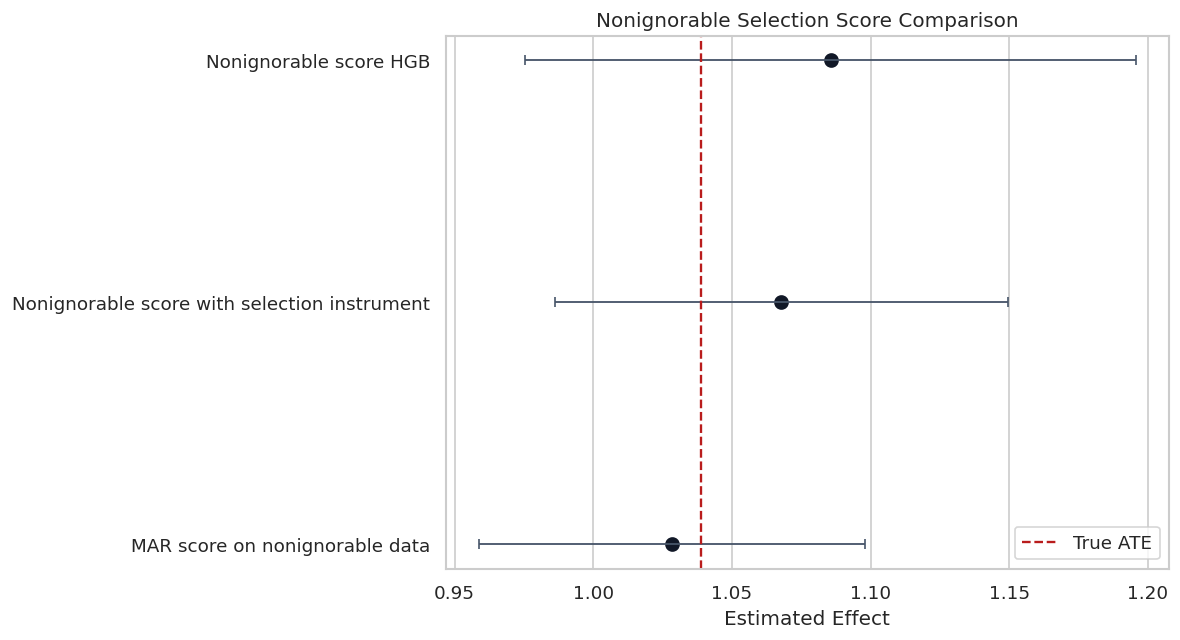

In [22]:
# Build and label the diagnostic visualization for the Nonignorable Estimate Plot section.
plot_non = add_ci_columns(nonignorable_summary)
fig, ax = plt.subplots(figsize=(10, 5.5))
order = plot_non.sort_values("theta_hat", ascending=False)["estimator"]
sns.pointplot(
    data=plot_non,
    y="estimator",
    x="theta_hat",
    order=order,
    linestyle="none",
    color="#111827",
    errorbar=None,
    ax=ax,
)
for y_pos, (_, row) in enumerate(plot_non.set_index("estimator").loc[order].reset_index().iterrows()):
    ax.errorbar(
        x=row["theta_hat"],
        y=y_pos,
        xerr=[[row["lower_error"]], [row["upper_error"]]],
        fmt="none",
        color="#475569",
        capsize=3,
        linewidth=1.1,
    )
ax.axvline(TRUE_NON_ATE, color="#b91c1c", linestyle="--", linewidth=1.4, label="True ATE")
ax.set_title("Nonignorable Selection Score Comparison")
ax.set_xlabel("Estimated Effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nonignorable_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The figure makes the design choice visible. When hidden response behavior matters, a missing-at-random score is answering under the wrong assumption, even if it runs cleanly.




## Reporting and Takeaways

### Combined Summary Table

This table collects the main estimates from the notebook. The rows should be compared within their design setting, not as interchangeable models.

In [23]:
combined_ssm_summary = pd.concat(
    [
        baseline_summary.assign(section="MAR data baselines"),
        manual_mar_summary.assign(section="MAR data manual score"),
        mar_doubleml_summary.assign(section="MAR data DoubleML"),
        nonignorable_summary.assign(section="nonignorable data"),
    ],
    ignore_index=True,
    sort=False,
)
save_table(combined_ssm_summary, f"{NOTEBOOK_PREFIX}_combined_ssm_summary.csv")
display(combined_ssm_summary)


,estimator,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target,section,design
0,Selected-row treated-control difference,1.675867,NaN,NaN,NaN,1.032326,0.643540,MAR data baselines,NaN
1,Synthetic full-population treated-control difference,1.732946,NaN,NaN,NaN,1.032326,0.700620,MAR data baselines,NaN
2,Selected-row OLS with covariates,1.065852,0.026952,1.013027,1.118678,1.032326,0.033526,MAR data baselines,NaN
3,Manual cross-fitted MAR SSM,1.003513,0.030544,0.943647,1.063380,1.032326,-0.028813,MAR data manual score,NaN
4,MAR linear,1.003229,0.030373,0.943700,1.062758,1.032326,-0.029098,MAR data DoubleML,missing-at-random
5,MAR HGB,0.987377,0.036071,0.916678,1.058076,1.032326,-0.044949,MAR data DoubleML,missing-at-random
6,MAR HGB normalized IPW,1.020675,0.017833,0.985723,1.055626,1.032326,-0.011652,MAR data DoubleML,missing-at-random
7,MAR score on nonignorable data,1.028351,0.035555,0.958665,1.098037,1.038926,-0.010575,nonignorable data,nonignorable data
8,Nonignorable score with selection instrument,1.067830,0.041649,0.986200,1.149460,1.038926,0.028904,nonignorable data,nonignorable data
9,Nonignorable score HGB,1.085624,0.056173,0.975527,1.195721,1.038926,0.046698,nonignorable data,nonignorable data


The combined table shows the notebook's main story: selected-row-only estimates can be very misleading, missing-at-random correction works when its assumptions match the data, and nonignorable selection requires stronger structure.

### Reporting Checklist

A sample-selection report needs more than an effect estimate. The checklist below names the assumptions and diagnostics a reader should see.

| topic | question | notebook_answer |
| --- | --- | --- |
| target population | Is the effect for all rows or selected rows only? | The main target is the full-population ATE. |
| selection definition | What does S=1 mean? | The outcome is observed. |
| unselected rows | Were unselected rows retained? | Yes. They enter treatment and selection nuisance models. |
| MAR assumption | Can observed D and X explain outcome observation? | True in the MAR synthetic design, false in the nonignorable design. |
| selection overlap | Are selection probabilities away from zero? | Checked with selection-probability histograms and stress tests. |
| treatment overlap | Are treatment propensities away from zero and one? | Checked with treatment-propensity histograms. |
| nonignorable selection | If MAR is not credible, is there a valid selection instrument? | The tutorial uses a synthetic selection encouragement as z_cols. |
| uncertainty | Are intervals and diagnostics reported? | Yes. Standard errors, bootstrap CI, and nuisance diagnostics are saved. |


This checklist turns the notebook into a reusable analysis template. The estimate is only one part of the evidence; the selection story is equally important.

### Report Template

The final report template writes the preferred MAR result and the nonignorable comparison in plain language. The language is cautious because sample selection assumptions are often the hardest part of the design.

In [24]:
best_mar = mar_doubleml_summary.loc[mar_doubleml_summary["estimator"] == "MAR HGB"].iloc[0]
best_non = nonignorable_summary.loc[nonignorable_summary["estimator"] == "Nonignorable score with selection instrument"].iloc[0]

report_text = f"""
# Sample Selection DoubleML Report Template

## Question

Estimate the treatment effect for the full target population when the outcome is observed only for selected rows.

## Preferred Missing-At-Random Result

The preferred MAR estimate uses `DoubleMLSSM` with gradient boosting nuisance learners.

- Estimate: {best_mar['theta_hat']:.4f}
- Standard error: {best_mar['std_error']:.4f}
- 95 percent CI: [{best_mar['ci_95_lower']:.4f}, {best_mar['ci_95_upper']:.4f}]
- Synthetic true ATE: {TRUE_MAR_ATE:.4f}

## Nonignorable Selection Demonstration

When selection depends on a hidden response factor, a MAR score is not conceptually sufficient. The nonignorable score uses a selection encouragement variable as an exclusion variable.

- Nonignorable estimate: {best_non['theta_hat']:.4f}
- Standard error: {best_non['std_error']:.4f}
- 95 percent CI: [{best_non['ci_95_lower']:.4f}, {best_non['ci_95_upper']:.4f}]
- Synthetic true ATE: {TRUE_NON_ATE:.4f}

## Assumptions To State

- Treatment assignment is unconfounded after conditioning on observed covariates.
- Outcome observation is missing at random after conditioning on treatment and covariates, unless using the nonignorable score.
- Treatment and selection probabilities have adequate overlap.
- For nonignorable selection, the selection encouragement affects outcome observation and has no direct outcome effect.

## Diagnostics To Include

- Selected versus unselected covariate balance.
- Treatment and selection probability overlap.
- Selected-row baseline estimates versus selection-adjusted estimates.
- Nuisance learner diagnostics.
- Stress test showing how lower outcome visibility affects uncertainty.
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_ssm_report_template.md"
report_path.write_text(report_text)
print(report_text)


# Sample Selection DoubleML Report Template

## Question

Estimate the treatment effect for the full target population when the outcome is observed only for selected rows.

## Preferred Missing-At-Random Result

The preferred MAR estimate uses `DoubleMLSSM` with gradient boosting nuisance learners.

- Estimate: 0.9874
- Standard error: 0.0361
- 95 percent CI: [0.9167, 1.0581]
- Synthetic true ATE: 1.0323

## Nonignorable Selection Demonstration

When selection depends on a hidden response factor, a MAR score is not conceptually sufficient. The nonignorable score uses a selection encouragement variable as an exclusion variable.

- Nonignorable estimate: 1.0678
- Standard error: 0.0416
- 95 percent CI: [0.9862, 1.1495]
- Synthetic true ATE: 1.0389

## Assumptions To State

- Treatment assignment is unconfounded after conditioning on observed covariates.
- Outcome observation is missing at random after conditioning on treatment and covariates, unless using the nonignorable score.
- Treatm

The report template keeps the estimate tied to its assumptions. That is especially important for selected-outcome data, where the missing outcomes are precisely the part we cannot inspect directly.

The sample-selection notebook is complete. The next natural topic is regression discontinuity design, where identification comes from continuity around a cutoff rather than selection correction, instruments, or parallel trends.